## Load the celebA Dataset

In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define the same transforms as before
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # RGB → 1 channel
    transforms.Resize((64, 64)),                 # Resize to 64x64
    transforms.ToTensor()                        # Convert to [0, 1] tensor
])

# 2. Point to the ROOT directory
# Note: root should contain a sub-folder (e.g., 'img_align_celeba') 
# that holds the .jpg files.
root_path = "../data/celeba" 

dataset = datasets.ImageFolder(
    root=root_path,
    transform=transform
)

# 3. Create the Loader
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Sanity check: Print number of images
print(f"Total images loaded: {len(dataset)}")

Total images loaded: 23429


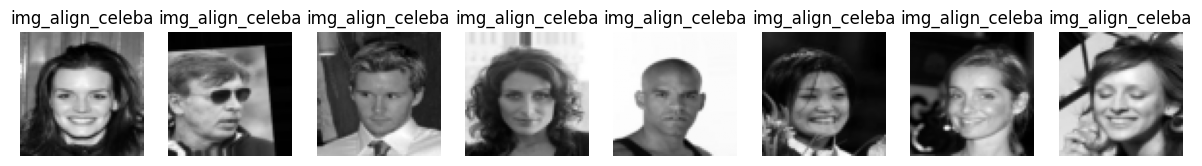

In [2]:
import matplotlib.pyplot as plt

images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(15,3))

for i in range(8):
    axes[i].imshow(images[i].permute(1,2,0), cmap = "grey")
    axes[i].set_title(dataset.classes[labels[i]])
    axes[i].axis("off")

plt.show()

## Model Building

In [3]:
import torch
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F

class LinearLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.rand(self.in_features, self.out_features))
        self.bias = nn.Parameter(torch.rand(self.out_features))

        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)
    
    def forward(self, x: torch.tensor):
        return x @ self.weight + self.bias

class LayerNorm(nn.Module):
    def __init__(self, in_features: int, eps: float = 0.001):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(in_features))
        self.shift = nn.Parameter(torch.zeros(in_features))
        self.eps = eps
    
    def forward(self, x: torch.tensor):
        x_mean = x.mean(dim = -1, keepdim = True)
        x_var = x.var(dim = - 1, keepdim = True, unbiased = False)
        x_norm = (x - x_mean) / (torch.sqrt(x_var + self.eps))
        return self.scale * x_norm + self.shift


class Encoder(nn.Module):
    def __init__(self, in_features: int, hidden_enc: int, latent_dim: int):
        super().__init__()
        self.linear_layer_1 = LinearLayer(in_features, hidden_enc)
        self.linear_layer_2 = LinearLayer(hidden_enc, hidden_enc)
        self.mean_layer = LinearLayer(hidden_enc, latent_dim)
        self.log_var_layer = LinearLayer(hidden_enc, latent_dim)
        self.layer_norm_1 = LayerNorm(hidden_enc)
        self.layer_norm_2 = LayerNorm(hidden_enc)
    
    def forward(self, x: torch.tensor):
        h1 = self.linear_layer_1(x)
        h1 = self.layer_norm_1(h1)
        h1 = F.relu(h1)

        h2 = self.linear_layer_2(h1)
        h2 = self.layer_norm_2(h2)
        h2 = F.relu(h2)

        mean = self.mean_layer(h2)
        log_var = self.log_var_layer(h2)
        return mean, log_var
    
    def reparameterization(self, mu: torch.tensor, log_var: torch.tensor):
        # sample eps from Gaussian Standard Normal Distribution
        eps = torch.randn_like(mu)
        std = torch.exp(0.5 * log_var)
        z = mu + std * eps
        return z


class Decoder(nn.Module):
    def __init__(self, latent_dim: int, hidden_dec: int, out_features: int):
        super().__init__()
        self.latent_dim = latent_dim
        self.linear_layer_1 = LinearLayer(latent_dim, hidden_dec)
        self.linear_layer_2 = LinearLayer(hidden_dec, hidden_dec)
        self.linear_layer_3 = LinearLayer(hidden_dec, out_features)
        self.layer_norm_1 = LayerNorm(hidden_dec)
        self.layer_norm_2 = LayerNorm(hidden_dec)
    
    def forward(self, z: torch.tensor):
        h1 = self.linear_layer_1(z)
        h1 = self.layer_norm_1(h1)
        h1 = F.relu(h1)

        h2 = self.linear_layer_2(h1)
        h2 = self.layer_norm_2(h2)
        h2 = F.relu(h2)

        logits = self.linear_layer_3(h2)
        return logits


class VAE(nn.Module):
    def __init__(self, in_features: int, hidden_enc: int, hidden_dec: int, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(in_features, hidden_enc, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dec, in_features)
    
    def forward(self, x: torch.tensor):
        mean, log_var = self.encoder(x)
        z = self.encoder.reparameterization(mean, log_var)
        logits = self.decoder(z)
        return (mean, log_var), logits
    
    def kl_divergence(self, mu: torch.tensor, log_var: torch.tensor):
        return -0.5 * torch.sum(1 + log_var - torch.exp(log_var) - mu.pow(2), dim=-1)

def train_fvsbn_model(model: VAE, loader: DataLoader, epochs: int, optimizer: torch.optim, device: torch.device, anneal_epochs: int = 40):
    model.to(device)
    
    # Outer progress bar for epochs
    epoch_bar = tqdm(range(epochs), desc="Training Progress", position=0)
    
    for epoch in epoch_bar:
        model.train()
        total_recon = 0
        total_kl = 0
        
        # Calculate beta for annealing (optional, currently using 0.001 constant in your logic)
        beta = min(1.0, epoch / anneal_epochs)
        
        # Inner progress bar for batches
        batch_bar = tqdm(loader, desc=f"Epoch {epoch+1}", leave=False, position=1)

        for images, _ in batch_bar:
            # Flatten images for the Linear VAE
            x = images.view(images.size(0), -1).to(device)

            # Forward pass
            (mean, log_var), reconstructed_x = model(x)
            
            # Reconstruction Loss
            recon_loss = F.binary_cross_entropy_with_logits(
                reconstructed_x, x, reduction="mean"
            )
            
            # KL Divergence
            kl_val = model.kl_divergence(mean, log_var)
            kl_loss = torch.mean(kl_val)

            # Combined Loss with your 0.001 scaling
            loss = recon_loss + (kl_loss * 0.001)
            
            if torch.isnan(loss):
                print(f"\nNaN detected at Epoch {epoch}, stopping training.")
                return model

            # Optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulate stats
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

            # Update the inner bar with specific loss components
            batch_bar.set_postfix({
                "Recon": f"{recon_loss.item():.4f}",
                "KL": f"{kl_loss.item():.4f}"
            })

        # Calculate averages for the epoch
        avg_recon = total_recon / len(loader)
        avg_kl = total_kl / len(loader)
        avg_total = avg_recon + (avg_kl * 0.001)

        # Update outer bar with summary
        epoch_bar.set_postfix({"Avg Recon": f"{avg_recon:.4f}", "Avg KL": f"{avg_kl:.4f}"})

        if epoch % 10 == 0:
            print(f"\nEpoch [{epoch}/{epochs}] | Avg Recon: {avg_recon:.4f} | Avg KL: {avg_kl:.4f} | Total: {avg_total:.4f}")

    return model

## Model Traning

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
in_features = images[0].shape[-1] * images[0].shape[-1]
out_features = images[0].shape[-1] * images[0].shape[-1]
hidden_enc = 1024
hidden_dec = 1024
latent_dim = 128
lr = 2e-4
vae = VAE(in_features, hidden_enc, hidden_dec, latent_dim)
optimizer = torch.optim.Adam(params = vae.parameters(), lr = lr)
trained_vae = train_fvsbn_model(
    model = vae,
    loader = loader,
    epochs = 200,
    optimizer = optimizer,
    device = device
)

Training Progress:   0%|          | 1/200 [00:25<1:25:03, 25.65s/it, Avg Recon=0.6325, Avg KL=6.1583]


Epoch [0/200] | Avg Recon: 0.6325 | Avg KL: 6.1583 | Total: 0.6387


Training Progress:   6%|▌         | 11/200 [04:54<1:24:11, 26.73s/it, Avg Recon=0.5640, Avg KL=14.0065]


Epoch [10/200] | Avg Recon: 0.5640 | Avg KL: 14.0065 | Total: 0.5780


Training Progress:  10%|█         | 21/200 [08:59<1:10:27, 23.62s/it, Avg Recon=0.5538, Avg KL=15.6021]

...

Training Progress:  90%|█████████ | 181/200 [1:21:10<07:18, 23.09s/it, Avg Recon=0.5406, Avg KL=18.8194]


Epoch [180/200] | Avg Recon: 0.5406 | Avg KL: 18.8194 | Total: 0.5594


Training Progress:  96%|█████████▌| 191/200 [1:25:01<03:27, 23.08s/it, Avg Recon=0.5404, Avg KL=18.9023]


Epoch [190/200] | Avg Recon: 0.5404 | Avg KL: 18.9023 | Total: 0.5593


Training Progress: 100%|██████████| 200/200 [1:28:29<00:00, 26.55s/it, Avg Recon=0.5401, Avg KL=18.9474]


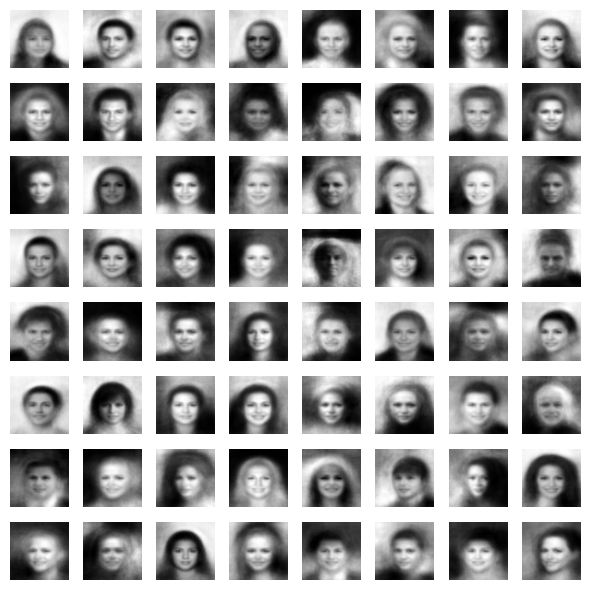

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def generate_new_images(model, n_images=64, image_size=64, device="cpu"):
    model.to(device) 
    model.eval()

    latent_dim = model.decoder.latent_dim

    cols = int(np.sqrt(n_images))
    rows = int(np.ceil(n_images / cols))

    fig, ax = plt.subplots(rows, cols, figsize=(6,6))

    with torch.no_grad():

        for i in range(n_images):

            z = torch.randn(1, latent_dim).to(device)
            logits = model.decoder(z)
            x_tilde = torch.sigmoid(logits)

            img = x_tilde.cpu().view(image_size, image_size)

            r = i // cols
            c = i % cols

            ax[r,c].imshow(img, cmap="gray")
            ax[r,c].axis("off")

    plt.tight_layout()
    plt.show()
generate_new_images(model = trained_vae)

## Saving the Model

In [7]:
import torch

save_path = "../saved_models/vae_01_celeba_.pth"
checkpoint = {
    
    "model_state_dict": trained_vae.state_dict(),

    "config": {
        "in_features": 64 * 64,
        "hidden_enc": 1024,
        "hidden_dec": 1024,
        "latent_dim": 128
    }

}
torch.save(checkpoint, save_path)
print("Model saved successfully")

Model saved successfully


## Loading the Model

In [8]:
import torch

load_path = "../saved_models/vae_01_celeba_.pth"

checkpoint = torch.load(load_path, map_location="cpu")

config = checkpoint["config"]

model = VAE(

    in_features = config["in_features"],
    hidden_enc = config["hidden_enc"],
    hidden_dec = config["hidden_dec"],
    latent_dim = config["latent_dim"]

)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()
print("Model loaded successfully")

Model loaded successfully


C:\Users\Himanshu Singh\AppData\Local\Temp\ipykernel_10120\3667649552.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(load_path, map_location="cp

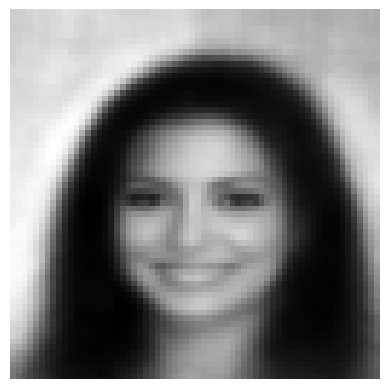

In [43]:
import matplotlib.pyplot as plt
z = torch.randn(1, latent_dim).to("cpu")
logits = model.decoder(z)
x_tilde = torch.sigmoid(logits)

img = x_tilde.cpu().view(64, 64)

plt.imshow(img.detach().numpy(), cmap="gray")
plt.axis("off")
plt.show()